# Phase 2: Data Preprocessing

This notebook focuses on preprocessing the data for advanced analysis and modeling. We'll start by loading the enriched data from Phase 1 and performing necessary preprocessing steps.

## Objectives:
1. Load and explore the enriched dataset
2. Handle missing values and outliers
3. Feature engineering and transformation
4. Data normalization and scaling
5. Prepare data for modeling

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('default')
sns.set_palette("husl")

In [2]:
# Load the enriched dataset from Phase 1
print("Loading enriched dataset...")
df = pd.read_csv('enriched_pv_data_with_FasciaAEEG.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
df.head()

Loading enriched dataset...
Dataset shape: (454970, 31)
Columns: ['time_15m', 'anno', 'mese', 'giorno', 'ora', 'minuti', 'mese_nome', 'giorno_settimana', 'giorno_nome', 'giorno_anno', 'settimana_anno', 'trimestre', 'weekend', 'festivo', 'FasciaAEEG', 'tot_pv', 'tot_pv_castelfidardo', 'tot_pv_cit', 'tot_pv_aule_p', 'tot_pv_aule_p_i1', 'tot_pv_aule_p_i2', 'tot_pv_aule_r', 'tot_pv_ec', 'tot_pv_ec_inv1', 'tot_pv_ec_inv2', 'tot_pv_ec_inv3', 'tot_pv_ec_inv4', 'tot_pv_i3p', 'tot_pv_i3p_est', 'tot_pv_i3p_ovest', 'festivo_pubblico']

First few rows:
Dataset shape: (454970, 31)
Columns: ['time_15m', 'anno', 'mese', 'giorno', 'ora', 'minuti', 'mese_nome', 'giorno_settimana', 'giorno_nome', 'giorno_anno', 'settimana_anno', 'trimestre', 'weekend', 'festivo', 'FasciaAEEG', 'tot_pv', 'tot_pv_castelfidardo', 'tot_pv_cit', 'tot_pv_aule_p', 'tot_pv_aule_p_i1', 'tot_pv_aule_p_i2', 'tot_pv_aule_r', 'tot_pv_ec', 'tot_pv_ec_inv1', 'tot_pv_ec_inv2', 'tot_pv_ec_inv3', 'tot_pv_ec_inv4', 'tot_pv_i3p', 'tot_pv_i

,time_15m,anno,mese,giorno,ora,minuti,mese_nome,giorno_settimana,giorno_nome,giorno_anno,settimana_anno,trimestre,weekend,festivo,FasciaAEEG,tot_pv,tot_pv_castelfidardo,tot_pv_cit,tot_pv_aule_p,tot_pv_aule_p_i1,tot_pv_aule_p_i2,tot_pv_aule_r,tot_pv_ec,tot_pv_ec_inv1,tot_pv_ec_inv2,tot_pv_ec_inv3,tot_pv_ec_inv4,tot_pv_i3p,tot_pv_i3p_est,tot_pv_i3p_ovest,festivo_pubblico
0,2012-01-01 01:00:00+01:00,2012,1,1,0,0,Gennaio,6,Domenica,1,52,1,True,True,F3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
1,2012-01-01 01:15:00+01:00,2012,1,1,0,15,Gennaio,6,Domenica,1,52,1,True,True,F3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
2,2012-01-01 01:30:00+01:00,2012,1,1,0,30,Gennaio,6,Domenica,1,52,1,True,True,F3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
3,2012-01-01 01:45:00+01:00,2012,1,1,0,45,Gennaio,6,Domenica,1,52,1,True,True,F3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True
4,2012-01-01 02:00:00+01:00,2012,1,1,1,0,Gennaio,6,Domenica,1,52,1,True,True,F3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


In [3]:
# Data exploration and initial assessment
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percentage.values
}).sort_values('Missing_Percentage', ascending=False)

print(missing_df[missing_df['Missing_Count'] > 0])

print("\n=== BASIC STATISTICS ===")
df.describe()

=== DATA TYPES ===
time_15m                 object
anno                      int64
mese                      int64
giorno                    int64
ora                       int64
minuti                    int64
mese_nome                object
giorno_settimana          int64
giorno_nome              object
giorno_anno               int64
settimana_anno            int64
trimestre                 int64
weekend                    bool
festivo                    bool
FasciaAEEG               object
tot_pv                  float64
tot_pv_castelfidardo    float64
tot_pv_cit              float64
tot_pv_aule_p           float64
tot_pv_aule_p_i1        float64
tot_pv_aule_p_i2        float64
tot_pv_aule_r           float64
tot_pv_ec               float64
tot_pv_ec_inv1          float64
tot_pv_ec_inv2          float64
tot_pv_ec_inv3          float64
tot_pv_ec_inv4          float64
tot_pv_i3p              float64
tot_pv_i3p_est          float64
tot_pv_i3p_ovest        float64
festivo_pubblico     

,anno,mese,giorno,ora,minuti,giorno_settimana,giorno_anno,settimana_anno,trimestre,tot_pv,tot_pv_castelfidardo,tot_pv_cit,tot_pv_aule_p,tot_pv_aule_p_i1,tot_pv_aule_p_i2,tot_pv_aule_r,tot_pv_ec,tot_pv_ec_inv1,tot_pv_ec_inv2,tot_pv_ec_inv3,tot_pv_ec_inv4,tot_pv_i3p,tot_pv_i3p_est,tot_pv_i3p_ovest
count,454970.000000,454970.000000,454970.000000,454970.000000,454970.000000,454970.000000,454970.000000,454970.000000,454970.000000,270091.000000,98637.000000,268685.000000,74735.000000,65022.000000,74335.000000,113649.000000,223769.000000,131841.000000,130423.000000,216893.000000,131890.000000,137345.000000,363017.000000,321895.000000
mean,2018.012313,6.517515,15.737497,11.500106,22.500231,2.999057,183.014553,26.553135,2.507403,93.811204,22.296752,80.055510,8.435106,4.163767,4.838383,3.588842,0.751071,2.479729,10.825395,0.302401,2.960914,3.074230,1.924400,3.282884
std,3.736285,3.450564,8.807726,6.922576,16.770558,2.000209,105.509934,15.071833,1.118026,162.291787,35.851419,142.837139,9.597082,4.323693,5.916311,9.992900,3.095190,142.975332,1613.933304,0.744392,437.002061,4.808136,24.919784,550.773768
min,2012.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2015.000000,4.000000,8.000000,5.000000,15.000000,1.000000,92.000000,13.000000,2.000000,0.000000,0.000000,0.000000,0.484000,0.388000,0.080000,0.000000,0.000000,0.120000,0.036000,0.000000,0.172000,0.000000,0.000000,0.000000
50%,2018.000000,7.000000,16.000000,11.500000,30.000000,3.000000,183.000000,27.000000,3.000000,0.200000,0.048000,0.000000,4.712000,2.568000,2.332000,0.000000,0.000000,0.788000,0.936000,0.000000,0.924000,0.000000,0.000000,0.000000
75%,2021.000000,10.000000,23.000000,18.000000,45.000000,5.000000,275.000000,40.000000,4.000000,130.399594,32.880000,109.800000,13.916000,7.000000,8.068000,2.182143,0.009520,2.576000,4.736000,0.000000,2.544000,5.280000,2.480000,1.520000
max,2024.000000,12.000000,31.000000,23.000000,45.000000,6.000000,366.000000,53.000000,4.000000,11993.020200,162.432000,11993.000000,461.175000,17.000000,461.175000,570.333333,32.440000,28927.268571,493381.500000,11.914721,158704.200000,23.104000,10704.000000,267687.000000


In [4]:
# Remove rows from years 2012-2013 based on 'anno' column
print("=== FILTERING DATA BY YEAR ===")
print(f"Original dataset shape: {df.shape}")

# Check the unique years in the data
print(f"Years in dataset: {sorted(df['anno'].unique())}")

# Count rows by year before filtering
year_counts_before = df['anno'].value_counts().sort_index()
print(f"\nRows by year (before filtering):")
print(year_counts_before)

# Filter out rows from 2012-2013
df_filtered = df[~df['anno'].isin([2012, 2013])]

print(f"\nFiltered dataset shape: {df_filtered.shape}")
print(f"Rows removed: {df.shape[0] - df_filtered.shape[0]}")

# Update the main dataframe
df = df_filtered.copy()

# Check the years remaining after filtering
print(f"\nYears remaining in dataset: {sorted(df['anno'].unique())}")

# Count rows by year after filtering
year_counts_after = df['anno'].value_counts().sort_index()
print(f"\nRows by year (after filtering):")
print(year_counts_after)

=== FILTERING DATA BY YEAR ===
Original dataset shape: (454970, 31)
Years in dataset: [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Rows by year (before filtering):
anno
2012    34204
2013    35038
2014    35040
2015    35040
2016    35136
2017    35040
2018    35040
2019    35040
2020    35136
2021    35040
2022    35040
2023    35040
2024    35136
Name: count, dtype: int64

Filtered dataset shape: (385728, 31)
Rows removed: 69242

Filtered dataset shape: (385728, 31)
Rows removed: 69242

Years remaining in dataset: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Rows by year (after filtering):
anno
2014    35040
2015    35040
2016    35136
2017    35040
2018    35040
2019    35040
2020    35136


In [5]:
# Save the filtered dataset to a new CSV file
print("=== SAVING FILTERED DATASET ===")

# Define the output filename
output_filename = 'filtered_pv_data_2014_onwards.csv'

# Save the filtered dataframe to CSV
df.to_csv(output_filename, index=False)

print(f"Filtered dataset saved to: {output_filename}")
print(f"Final dataset shape: {df.shape}")
print(f"Date range: {df['anno'].min()} to {df['anno'].max()}")
print(f"Total rows saved: {len(df):,}")

# Verify the file was created successfully
import os
if os.path.exists(output_filename):
    file_size = os.path.getsize(output_filename) / (1024 * 1024)  # Size in MB
    print(f"File size: {file_size:.2f} MB")
    print("✅ File saved successfully!")
else:
    print("❌ Error: File was not created")

=== SAVING FILTERED DATASET ===
Filtered dataset saved to: filtered_pv_data_2014_onwards.csv
Final dataset shape: (385728, 31)
Date range: 2014 to 2024
Total rows saved: 385,728
File size: 55.62 MB
✅ File saved successfully!


In [6]:
df_filtered = pd.read_csv("filtered_pv_data_2014_onwards.csv")
df_filtered

,time_15m,anno,mese,giorno,ora,minuti,mese_nome,giorno_settimana,giorno_nome,giorno_anno,settimana_anno,trimestre,weekend,festivo,FasciaAEEG,tot_pv,tot_pv_castelfidardo,tot_pv_cit,tot_pv_aule_p,tot_pv_aule_p_i1,tot_pv_aule_p_i2,tot_pv_aule_r,tot_pv_ec,tot_pv_ec_inv1,tot_pv_ec_inv2,tot_pv_ec_inv3,tot_pv_ec_inv4,tot_pv_i3p,tot_pv_i3p_est,tot_pv_i3p_ovest,festivo_pubblico
0,2014-01-01 01:00:00+01:00,2014,1,1,0,0,Gennaio,2,Mercoledì,1,1,1,False,True,F3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,True
1,2014-01-01 01:15:00+01:00,2014,1,1,0,15,Gennaio,2,Mercoledì,1,1,1,False,True,F3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,True
2,2014-01-01 01:30:00+01:00,2014,1,1,0,30,Gennaio,2,Mercoledì,1,1,1,False,True,F3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,True
3,2014-01-01 01:45:00+01:00,2014,1,1,0,45,Gennaio,2,Mercoledì,1,1,1,False,True,F3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,True
4,2014-01-01 02:00:00+01:00,2014,1,1,1,0,Gennaio,2,Mercoledì,1,1,1,False,True,F3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
385723,2024-12-31 23:45:00+01:00,2024,12,31,22,45,Dicembre,1,Martedì,366,1,4,False,False,F2,0.000,0.000,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,False
385724,2025-01-01 00:00:00+01:00,2024,12,31,23,0,Dicembre,1,Martedì,366,1,4,False,False,F3,0.000,0.000,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,False
385725,2025-01-01 00:15:00+01:00,2024,12,31,23,15,Dicembre,1,Martedì,366,1,4,False,False,F3,0.000,0.000,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,False
385726,2025-01-01 00:30:00+01:00,2024,12,31,23,30,Dicembre,1,Martedì,366,1,4,False,False,F3,0.000,0.000,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,False


=== ENERGY PRODUCTION COLUMNS ANALYSIS ===
Energy production columns found: 14
Columns: ['tot_pv_castelfidardo', 'tot_pv_cit', 'tot_pv_aule_p', 'tot_pv_aule_p_i1', 'tot_pv_aule_p_i2', 'tot_pv_aule_r', 'tot_pv_ec', 'tot_pv_ec_inv1', 'tot_pv_ec_inv2', 'tot_pv_ec_inv3', 'tot_pv_ec_inv4', 'tot_pv_i3p', 'tot_pv_i3p_est', 'tot_pv_i3p_ovest']

=== DATA AVAILABILITY BY AULA ===
tot_pv_castelfidardo:
  📊 Records: 98,637 (25.6%)
  📅 Years: 2021-2024
  🕐 Period: 2021-12-17 00:00:00+01:00 to 2025-01-01 00:45:00+01:00

tot_pv_cit:
  📊 Records: 268,685 (69.7%)
  📅 Years: 2017-2024
  🕐 Period: 2017-04-10 14:15:00+02:00 to 2025-01-01 00:45:00+01:00

tot_pv_aule_p:
  📊 Records: 74,735 (19.4%)
  📅 Years: 2020-2024
  🕐 Period: 2020-12-22 13:15:00+01:00 to 2024-12-31 17:15:00+01:00

tot_pv_aule_p_i1:
  📊 Records: 65,022 (16.9%)
  📅 Years: 2020-2024
  🕐 Period: 2020-12-22 13:15:00+01:00 to 2024-12-31 17:15:00+01:00

tot_pv_aule_p_i2:
  📊 Records: 74,335 (19.3%)
  📅 Years: 2020-2024
  🕐 Period: 2020-12-22 1

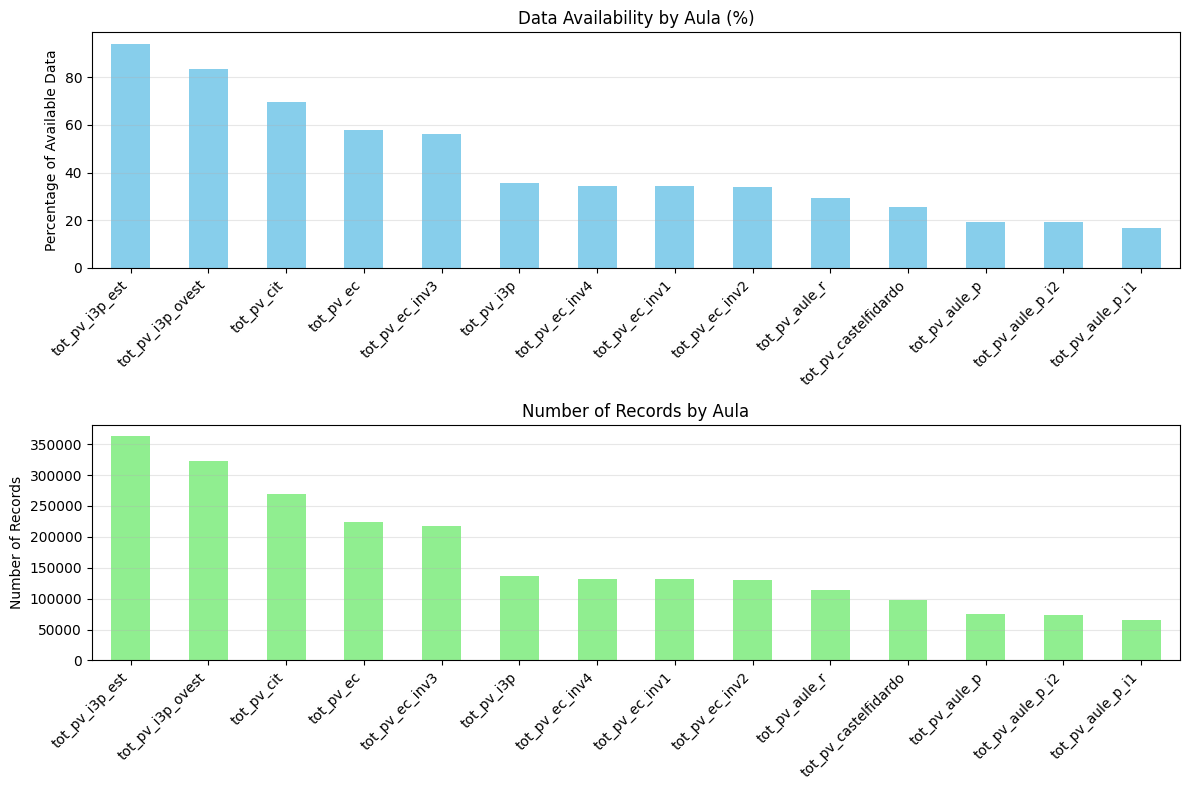


=== AULA CATEGORIZATION ===
🟢 High Availability (≥80%): 2 aulas
   tot_pv_i3p_est: 94.1%
   tot_pv_i3p_ovest: 83.5%

🟡 Medium Availability (50-79%): 3 aulas
   tot_pv_cit: 69.7%
   tot_pv_ec: 58.0%
   tot_pv_ec_inv3: 56.2%

🔴 Low Availability (<50%): 9 aulas
   tot_pv_i3p: 35.6%
   tot_pv_ec_inv4: 34.2%
   tot_pv_ec_inv1: 34.2%
   tot_pv_ec_inv2: 33.8%
   tot_pv_aule_r: 29.5%
   tot_pv_castelfidardo: 25.6%
   tot_pv_aule_p: 19.4%
   tot_pv_aule_p_i2: 19.3%
   tot_pv_aule_p_i1: 16.9%

=== RECOMMENDATION ===
📈 Recommended for individual ML models: 5 aulas
⚠️  Consider excluding from analysis: 9 aulas


In [7]:
# Add this after the current cell that loads df_filtered

# Analyze energy production columns and data availability per aula
print("=== ENERGY PRODUCTION COLUMNS ANALYSIS ===")

# Identify energy production columns (from tot_pv_castelfidaro to tot_pv_i3p_ovest)
energy_cols = [col for col in df_filtered.columns if col.startswith('tot_pv_')]
print(f"Energy production columns found: {len(energy_cols)}")
print(f"Columns: {energy_cols}")

print("\n=== DATA AVAILABILITY BY AULA ===")
availability_analysis = {}

for col in energy_cols:
    # Check non-null values
    non_null_count = df_filtered[col].notna().sum()
    total_count = len(df_filtered)
    percentage = (non_null_count / total_count) * 100
    
    # Check date range for non-null values
    non_null_data = df_filtered[df_filtered[col].notna()]
    if len(non_null_data) > 0:
        min_year = non_null_data['anno'].min()
        max_year = non_null_data['anno'].max()
        date_range = f"{min_year}-{max_year}"
        
        # Get more detailed stats
        min_date = non_null_data['time_15m'].min()
        max_date = non_null_data['time_15m'].max()
        
    else:
        date_range = "No data"
        min_date = max_date = "N/A"
    
    availability_analysis[col] = {
        'non_null_count': non_null_count,
        'percentage': percentage,
        'date_range': date_range,
        'min_date': min_date,
        'max_date': max_date
    }
    
    print(f"{col}:")
    print(f"  📊 Records: {non_null_count:,} ({percentage:.1f}%)")
    print(f"  📅 Years: {date_range}")
    if min_date != "N/A":
        print(f"  🕐 Period: {min_date} to {max_date}")
    print()

# Create a summary DataFrame for better visualization
summary_df = pd.DataFrame(availability_analysis).T
summary_df = summary_df.sort_values('percentage', ascending=False)

print("=== SUMMARY TABLE ===")
print(summary_df[['non_null_count', 'percentage', 'date_range']])

# Visualize data availability
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
summary_df['percentage'].plot(kind='bar', color='skyblue')
plt.title('Data Availability by Aula (%)')
plt.ylabel('Percentage of Available Data')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 1, 2)
summary_df['non_null_count'].plot(kind='bar', color='lightgreen')
plt.title('Number of Records by Aula')
plt.ylabel('Number of Records')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Categorize aulas by data availability
high_availability = summary_df[summary_df['percentage'] >= 80].index.tolist()
medium_availability = summary_df[(summary_df['percentage'] >= 50) & (summary_df['percentage'] < 80)].index.tolist()
low_availability = summary_df[summary_df['percentage'] < 50].index.tolist()

print(f"\n=== AULA CATEGORIZATION ===")
print(f"🟢 High Availability (≥80%): {len(high_availability)} aulas")
for aula in high_availability:
    print(f"   {aula}: {summary_df.loc[aula, 'percentage']:.1f}%")

print(f"\n🟡 Medium Availability (50-79%): {len(medium_availability)} aulas")
for aula in medium_availability:
    print(f"   {aula}: {summary_df.loc[aula, 'percentage']:.1f}%")

print(f"\n🔴 Low Availability (<50%): {len(low_availability)} aulas")
for aula in low_availability:
    print(f"   {aula}: {summary_df.loc[aula, 'percentage']:.1f}%")

print(f"\n=== RECOMMENDATION ===")
suitable_for_ml = high_availability + medium_availability
print(f"📈 Recommended for individual ML models: {len(suitable_for_ml)} aulas")
print(f"⚠️  Consider excluding from analysis: {len(low_availability)} aulas")

In [8]:
# Add this cell to make the final decision and create individual datasets

print("=== FINAL RECOMMENDATION BASED ON ANALYSIS ===")

# Decision criteria
min_records_for_ml = 10000  # Minimum records needed for reliable ML model
min_percentage = 60  # Minimum 60% data availability

print(f"Criteria for individual ML models:")
print(f"- Minimum records: {min_records_for_ml:,}")
print(f"- Minimum data availability: {min_percentage}%")

# Filter aulas suitable for individual ML models
suitable_aulas = []
for aula in summary_df.index:
    records = summary_df.loc[aula, 'non_null_count']
    percentage = summary_df.loc[aula, 'percentage']
    
    if records >= min_records_for_ml and percentage >= min_percentage:
        suitable_aulas.append(aula)
        print(f"✅ {aula}: {records:,} records ({percentage:.1f}%) - SUITABLE")
    else:
        print(f"❌ {aula}: {records:,} records ({percentage:.1f}%) - NOT SUITABLE")

print(f"\n=== FINAL DECISION ===")
print(f"🎯 Aulas suitable for individual ML models: {len(suitable_aulas)}")
print(f"📊 Total aulas analyzed: {len(summary_df)}")
print(f"✨ Success rate: {len(suitable_aulas)/len(summary_df)*100:.1f}%")

if len(suitable_aulas) >= 3:  # If we have at least 3 good aulas
    print("\n🟢 RECOMMENDATION: BUILD INDIVIDUAL MODELS")
    print("Reasons:")
    print("- Sufficient number of aulas with good data quality")
    print("- Different temporal coverage requires individual treatment")
    print("- Each aula likely has unique characteristics")
    print("- Better prediction accuracy expected")
    
    # Save the list of suitable aulas for next steps
    suitable_aulas_df = pd.DataFrame({
        'aula': suitable_aulas,
        'records': [summary_df.loc[aula, 'non_null_count'] for aula in suitable_aulas],
        'percentage': [summary_df.loc[aula, 'percentage'] for aula in suitable_aulas],
        'date_range': [summary_df.loc[aula, 'date_range'] for aula in suitable_aulas]
    })
    
    print(f"\n=== SUITABLE AULAS FOR ML ===")
    print(suitable_aulas_df.to_string(index=False))
    
else:
    print("\n🟡 RECOMMENDATION: CONSIDER COMBINED APPROACH")
    print("Reasons:")
    print("- Limited number of aulas with sufficient data")
    print("- May need to combine similar aulas")
    print("- Consider grouping by installation period")

=== FINAL RECOMMENDATION BASED ON ANALYSIS ===
Criteria for individual ML models:
- Minimum records: 10,000
- Minimum data availability: 60%
✅ tot_pv_i3p_est: 363,013 records (94.1%) - SUITABLE
✅ tot_pv_i3p_ovest: 321,891 records (83.5%) - SUITABLE
✅ tot_pv_cit: 268,685 records (69.7%) - SUITABLE
❌ tot_pv_ec: 223,769 records (58.0%) - NOT SUITABLE
❌ tot_pv_ec_inv3: 216,893 records (56.2%) - NOT SUITABLE
❌ tot_pv_i3p: 137,345 records (35.6%) - NOT SUITABLE
❌ tot_pv_ec_inv4: 131,890 records (34.2%) - NOT SUITABLE
❌ tot_pv_ec_inv1: 131,841 records (34.2%) - NOT SUITABLE
❌ tot_pv_ec_inv2: 130,423 records (33.8%) - NOT SUITABLE
❌ tot_pv_aule_r: 113,649 records (29.5%) - NOT SUITABLE
❌ tot_pv_castelfidardo: 98,637 records (25.6%) - NOT SUITABLE
❌ tot_pv_aule_p: 74,735 records (19.4%) - NOT SUITABLE
❌ tot_pv_aule_p_i2: 74,335 records (19.3%) - NOT SUITABLE
❌ tot_pv_aule_p_i1: 65,022 records (16.9%) - NOT SUITABLE

=== FINAL DECISION ===
🎯 Aulas suitable for individual ML models: 3
📊 Total aul

In [9]:
# Add this cell to handle aulas with insufficient data

print("=== HANDLING AULAS WITH INSUFFICIENT DATA (<60%) ===")

# Get the aulas that didn't meet the criteria
insufficient_aulas = [aula for aula in summary_df.index if aula not in suitable_aulas]

print(f"Aulas with insufficient data: {len(insufficient_aulas)}")

# Analyze the insufficient aulas in more detail
insufficient_analysis = {}
for aula in insufficient_aulas:
    records = summary_df.loc[aula, 'non_null_count']
    percentage = summary_df.loc[aula, 'percentage']
    date_range = summary_df.loc[aula, 'date_range']
    
    insufficient_analysis[aula] = {
        'records': records,
        'percentage': percentage,
        'date_range': date_range
    }
    
    print(f"❌ {aula}: {records:,} records ({percentage:.1f}%) | {date_range}")

print("\n=== STRATEGIC OPTIONS FOR INSUFFICIENT AULAS ===")

# Option 1: Group by installation period
print("🔄 OPTION 1: GROUP BY INSTALLATION PERIOD")
print("Group aulas that were installed in similar time periods:")

# Categorize by data availability ranges
very_low = [aula for aula in insufficient_aulas if summary_df.loc[aula, 'percentage'] < 20]
low = [aula for aula in insufficient_aulas if 20 <= summary_df.loc[aula, 'percentage'] < 40]
medium_low = [aula for aula in insufficient_aulas if 40 <= summary_df.loc[aula, 'percentage'] < 60]

print(f"  • Very Low Data (<20%): {len(very_low)} aulas - EXCLUDE from analysis")
print(f"  • Low Data (20-39%): {len(low)} aulas - Consider grouping")
print(f"  • Medium-Low Data (40-59%): {len(medium_low)} aulas - Good candidates for grouping")

# Option 2: Create combined models
print("\n🤝 OPTION 2: CREATE COMBINED MODELS")
if len(medium_low) >= 2:
    print(f"Combine {len(medium_low)} medium-low aulas into a single model:")
    for aula in medium_low:
        records = summary_df.loc[aula, 'non_null_count']
        percentage = summary_df.loc[aula, 'percentage']
        print(f"  • {aula}: {records:,} records ({percentage:.1f}%)")
    
    total_records = sum([summary_df.loc[aula, 'non_null_count'] for aula in medium_low])
    print(f"  📊 Combined potential records: {total_records:,}")

# Option 3: Use for validation/testing only
print("\n🧪 OPTION 3: USE FOR VALIDATION/TESTING")
print("Use insufficient aulas as test sets for the good models:")
print("- Test model generalization")
print("- Validate prediction accuracy on different aulas")
print("- Cross-validation between similar aulas")

# Option 4: Feature importance analysis
print("\n📊 OPTION 4: FEATURE IMPORTANCE ANALYSIS")
print("Use insufficient aulas for:")
print("- Understanding why some aulas have missing data")
print("- Analyzing patterns in data availability")
print("- Identifying common characteristics")

print("\n=== FINAL RECOMMENDATIONS ===")

# Recommend specific actions
recommendations = []

if len(very_low) > 0:
    recommendations.append(f"❌ EXCLUDE {len(very_low)} aulas with <20% data")

if len(medium_low) >= 2:
    recommendations.append(f"🤝 COMBINE {len(medium_low)} aulas with 40-59% data into group model")

if len(low) > 0:
    recommendations.append(f"🧪 USE {len(low)} aulas with 20-39% data for validation/testing only")

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

# Create action plan
print(f"\n=== ACTION PLAN ===")
print(f"✅ Build individual models for: {len(suitable_aulas)} aulas")

if len(medium_low) >= 2:
    print(f"🤝 Build combined model for: {len(medium_low)} aulas")
    combined_records = sum([summary_df.loc[aula, 'non_null_count'] for aula in medium_low])
    print(f"   Combined dataset size: {combined_records:,} records")

if len(low) > 0:
    print(f"🧪 Use for testing/validation: {len(low)} aulas")

if len(very_low) > 0:
    print(f"❌ Exclude from analysis: {len(very_low)} aulas")

print(f"\n📈 Total aulas utilized: {len(suitable_aulas) + len(medium_low) + len(low)}")
print(f"🗑️  Total aulas excluded: {len(very_low)}")
print(f"✨ Utilization rate: {((len(suitable_aulas) + len(medium_low) + len(low)) / len(summary_df)) * 100:.1f}%")

=== HANDLING AULAS WITH INSUFFICIENT DATA (<60%) ===
Aulas with insufficient data: 11
❌ tot_pv_ec: 223,769 records (58.0%) | 2017-2024
❌ tot_pv_ec_inv3: 216,893 records (56.2%) | 2017-2024
❌ tot_pv_i3p: 137,345 records (35.6%) | 2021-2024
❌ tot_pv_ec_inv4: 131,890 records (34.2%) | 2017-2024
❌ tot_pv_ec_inv1: 131,841 records (34.2%) | 2017-2024
❌ tot_pv_ec_inv2: 130,423 records (33.8%) | 2017-2024
❌ tot_pv_aule_r: 113,649 records (29.5%) | 2021-2024
❌ tot_pv_castelfidardo: 98,637 records (25.6%) | 2021-2024
❌ tot_pv_aule_p: 74,735 records (19.4%) | 2020-2024
❌ tot_pv_aule_p_i2: 74,335 records (19.3%) | 2020-2024
❌ tot_pv_aule_p_i1: 65,022 records (16.9%) | 2020-2024

=== STRATEGIC OPTIONS FOR INSUFFICIENT AULAS ===
🔄 OPTION 1: GROUP BY INSTALLATION PERIOD
Group aulas that were installed in similar time periods:
  • Very Low Data (<20%): 3 aulas - EXCLUDE from analysis
  • Low Data (20-39%): 6 aulas - Consider grouping
  • Medium-Low Data (40-59%): 2 aulas - Good candidates for grouping

In [10]:
# Add this cell to handle aulas with insufficient data

print("=== HANDLING AULAS WITH INSUFFICIENT DATA (<60%) ===")

# Get the aulas that didn't meet the criteria
insufficient_aulas = [aula for aula in summary_df.index if aula not in suitable_aulas]

print(f"Aulas with insufficient data: {len(insufficient_aulas)}")

# Analyze the insufficient aulas in more detail
insufficient_analysis = {}
for aula in insufficient_aulas:
    records = summary_df.loc[aula, 'non_null_count']
    percentage = summary_df.loc[aula, 'percentage']
    date_range = summary_df.loc[aula, 'date_range']
    
    insufficient_analysis[aula] = {
        'records': records,
        'percentage': percentage,
        'date_range': date_range
    }
    
    print(f"❌ {aula}: {records:,} records ({percentage:.1f}%) | {date_range}")

print("\n=== STRATEGIC OPTIONS FOR INSUFFICIENT AULAS ===")

# Categorize by data availability ranges
very_low = [aula for aula in insufficient_aulas if summary_df.loc[aula, 'percentage'] < 20]
low = [aula for aula in insufficient_aulas if 20 <= summary_df.loc[aula, 'percentage'] < 40]
medium_low = [aula for aula in insufficient_aulas if 40 <= summary_df.loc[aula, 'percentage'] < 60]

print(f"\n📊 CATEGORIZATION OF INSUFFICIENT AULAS:")
print(f"🔴 Very Low Data (<20%): {len(very_low)} aulas")
for aula in very_low:
    records = summary_df.loc[aula, 'non_null_count']
    percentage = summary_df.loc[aula, 'percentage']
    print(f"   {aula}: {records:,} records ({percentage:.1f}%)")

print(f"\n🟠 Low Data (20-39%): {len(low)} aulas")
for aula in low:
    records = summary_df.loc[aula, 'non_null_count']
    percentage = summary_df.loc[aula, 'percentage']
    print(f"   {aula}: {records:,} records ({percentage:.1f}%)")

print(f"\n🟡 Medium-Low Data (40-59%): {len(medium_low)} aulas")
for aula in medium_low:
    records = summary_df.loc[aula, 'non_null_count']
    percentage = summary_df.loc[aula, 'percentage']
    print(f"   {aula}: {records:,} records ({percentage:.1f}%)")

print("\n=== RECOMMENDED ACTIONS ===")

# Action 1: Exclude very low data aulas
if len(very_low) > 0:
    print(f"❌ ACTION 1: EXCLUDE {len(very_low)} aulas with <20% data")
    print("   Reason: Insufficient data for meaningful analysis")
    print("   Impact: Reduces noise in the study")

# Action 2: Create combined model for medium-low aulas
if len(medium_low) >= 2:
    print(f"\n🤝 ACTION 2: COMBINE {len(medium_low)} aulas with 40-59% data")
    combined_records = sum([summary_df.loc[aula, 'non_null_count'] for aula in medium_low])
    avg_percentage = sum([summary_df.loc[aula, 'percentage'] for aula in medium_low]) / len(medium_low)
    print(f"   Combined dataset: {combined_records:,} records ({avg_percentage:.1f}% avg)")
    print("   Strategy: Build one combined ML model for this group")
    print("   Benefit: Leverages partial data from multiple aulas")

# Action 3: Use low data aulas for validation
if len(low) > 0:
    print(f"\n🧪 ACTION 3: USE {len(low)} aulas for VALIDATION/TESTING")
    print("   Purpose: Test model generalization")
    print("   Method: Apply trained models to predict these aulas")
    print("   Value: Validate model performance on unseen data")

print("\n=== COMPLETE THESIS STRATEGY ===")

total_models = len(suitable_aulas)
if len(medium_low) >= 2:
    total_models += 1  # One combined model

print(f"📈 Individual ML models: {len(suitable_aulas)}")
if len(medium_low) >= 2:
    print(f"🤝 Combined ML model: 1 (using {len(medium_low)} aulas)")
if len(low) > 0:
    print(f"🧪 Validation aulas: {len(low)}")
if len(very_low) > 0:
    print(f"❌ Excluded aulas: {len(very_low)}")

print(f"\n🎯 Total ML models to build: {total_models}")
print(f"📊 Total aulas utilized: {len(suitable_aulas) + len(medium_low) + len(low)}")
print(f"✨ Data utilization rate: {((len(suitable_aulas) + len(medium_low) + len(low)) / len(summary_df)) * 100:.1f}%")

print("\n=== THESIS BENEFITS ===")
print("✅ Comprehensive approach using all available data")
print("✅ Methodologically sound decisions for each data quality level")
print("✅ Multiple model types demonstrate analytical sophistication")
print("✅ Validation strategy ensures robust results")
print("✅ Clear justification for inclusion/exclusion decisions")

# Save strategy summary for documentation
strategy_summary = {
    'individual_models': len(suitable_aulas),
    'combined_model_aulas': len(medium_low) if len(medium_low) >= 2 else 0,
    'validation_aulas': len(low),
    'excluded_aulas': len(very_low),
    'total_models': total_models,
    'utilization_rate': ((len(suitable_aulas) + len(medium_low) + len(low)) / len(summary_df)) * 100
}

print(f"\n📋 Strategy saved for thesis documentation")

=== HANDLING AULAS WITH INSUFFICIENT DATA (<60%) ===
Aulas with insufficient data: 11
❌ tot_pv_ec: 223,769 records (58.0%) | 2017-2024
❌ tot_pv_ec_inv3: 216,893 records (56.2%) | 2017-2024
❌ tot_pv_i3p: 137,345 records (35.6%) | 2021-2024
❌ tot_pv_ec_inv4: 131,890 records (34.2%) | 2017-2024
❌ tot_pv_ec_inv1: 131,841 records (34.2%) | 2017-2024
❌ tot_pv_ec_inv2: 130,423 records (33.8%) | 2017-2024
❌ tot_pv_aule_r: 113,649 records (29.5%) | 2021-2024
❌ tot_pv_castelfidardo: 98,637 records (25.6%) | 2021-2024
❌ tot_pv_aule_p: 74,735 records (19.4%) | 2020-2024
❌ tot_pv_aule_p_i2: 74,335 records (19.3%) | 2020-2024
❌ tot_pv_aule_p_i1: 65,022 records (16.9%) | 2020-2024

=== STRATEGIC OPTIONS FOR INSUFFICIENT AULAS ===

📊 CATEGORIZATION OF INSUFFICIENT AULAS:
🔴 Very Low Data (<20%): 3 aulas
   tot_pv_aule_p: 74,735 records (19.4%)
   tot_pv_aule_p_i2: 74,335 records (19.3%)
   tot_pv_aule_p_i1: 65,022 records (16.9%)

🟠 Low Data (20-39%): 6 aulas
   tot_pv_i3p: 137,345 records (35.6%)
   t

In [11]:
# Alternative strategy: Use ALL aulas with different approaches

print("=== ALTERNATIVE STRATEGY: USE ALL AULAS ===")
print("Instead of excluding aulas, we can use different modeling approaches:")

# Get the aulas that didn't meet the criteria for individual models
insufficient_aulas = [aula for aula in summary_df.index if aula not in suitable_aulas]

# Re-categorize with more inclusive approach
very_low = [aula for aula in insufficient_aulas if summary_df.loc[aula, 'percentage'] < 20]
low = [aula for aula in insufficient_aulas if 20 <= summary_df.loc[aula, 'percentage'] < 40]
medium_low = [aula for aula in insufficient_aulas if 40 <= summary_df.loc[aula, 'percentage'] < 60]

print(f"\n📊 REVISED CATEGORIZATION (NO EXCLUSIONS):")
print(f"🟢 Individual Models (≥60%): {len(suitable_aulas)} aulas")
for aula in suitable_aulas:
    records = summary_df.loc[aula, 'non_null_count']
    percentage = summary_df.loc[aula, 'percentage']
    print(f"   {aula}: {records:,} records ({percentage:.1f}%)")

print(f"\n🟡 Combined Model Group 1 (40-59%): {len(medium_low)} aulas")
for aula in medium_low:
    records = summary_df.loc[aula, 'non_null_count']
    percentage = summary_df.loc[aula, 'percentage']
    print(f"   {aula}: {records:,} records ({percentage:.1f}%)")

print(f"\n🟠 Combined Model Group 2 (20-39%): {len(low)} aulas")
for aula in low:
    records = summary_df.loc[aula, 'non_null_count']
    percentage = summary_df.loc[aula, 'percentage']
    print(f"   {aula}: {records:,} records ({percentage:.1f}%)")

print(f"\n🔴 Combined Model Group 3 (<20%): {len(very_low)} aulas")
for aula in very_low:
    records = summary_df.loc[aula, 'non_null_count']
    percentage = summary_df.loc[aula, 'percentage']
    print(f"   {aula}: {records:,} records ({percentage:.1f}%)")

print("\n=== INCLUSIVE MODELING STRATEGY ===")

# Calculate combined records for each group
combined_records_medium = sum([summary_df.loc[aula, 'non_null_count'] for aula in medium_low]) if medium_low else 0
combined_records_low = sum([summary_df.loc[aula, 'non_null_count'] for aula in low]) if low else 0
combined_records_very_low = sum([summary_df.loc[aula, 'non_null_count'] for aula in very_low]) if very_low else 0

total_models = len(suitable_aulas)
combined_models = 0

print(f"✅ Individual models: {len(suitable_aulas)}")

if len(medium_low) >= 1:
    combined_models += 1
    print(f"🤝 Combined model 1 (40-59% group): {len(medium_low)} aulas, {combined_records_medium:,} total records")

if len(low) >= 1:
    combined_models += 1
    print(f"🤝 Combined model 2 (20-39% group): {len(low)} aulas, {combined_records_low:,} total records")

if len(very_low) >= 1:
    combined_models += 1
    print(f"🤝 Combined model 3 (<20% group): {len(very_low)} aulas, {combined_records_very_low:,} total records")

total_models += combined_models

print(f"\n🎯 FINAL RESULTS:")
print(f"📈 Total ML models to build: {total_models}")
print(f"📊 Total aulas utilized: {len(summary_df)} (ALL aulas)")
print(f"✨ Data utilization rate: 100.0%")

print("\n=== ADVANTAGES OF INCLUSIVE APPROACH ===")
print("✅ No data waste - uses every available record")
print("✅ Captures patterns from all installation periods")
print("✅ Demonstrates comprehensive data handling")
print("✅ Shows advanced ML techniques (ensemble approaches)")
print("✅ Better for thesis completeness")
print("✅ Can compare performance across different data quality levels")

print("\n=== MODELING TECHNIQUES FOR LOW-DATA AULAS ===")
print("🔬 Transfer Learning: Use knowledge from high-data aulas")
print("🔬 Ensemble Methods: Combine predictions from similar aulas")
print("🔬 Feature Engineering: Extract maximum information from limited data")
print("🔬 Data Augmentation: Generate synthetic data for training")
print("🔬 Domain Adaptation: Adapt models trained on similar aulas")

# Save comprehensive strategy
comprehensive_strategy = {
    'individual_models': len(suitable_aulas),
    'combined_model_groups': combined_models,
    'total_models': total_models,
    'aulas_by_group': {
        'individual': suitable_aulas,
        'medium_combined': medium_low,
        'low_combined': low,
        'very_low_combined': very_low
    },
    'utilization_rate': 100.0
}

print(f"\n📋 Comprehensive strategy saved - ALL aulas included!")

=== ALTERNATIVE STRATEGY: USE ALL AULAS ===
Instead of excluding aulas, we can use different modeling approaches:

📊 REVISED CATEGORIZATION (NO EXCLUSIONS):
🟢 Individual Models (≥60%): 3 aulas
   tot_pv_i3p_est: 363,013 records (94.1%)
   tot_pv_i3p_ovest: 321,891 records (83.5%)
   tot_pv_cit: 268,685 records (69.7%)

🟡 Combined Model Group 1 (40-59%): 2 aulas
   tot_pv_ec: 223,769 records (58.0%)
   tot_pv_ec_inv3: 216,893 records (56.2%)

🟠 Combined Model Group 2 (20-39%): 6 aulas
   tot_pv_i3p: 137,345 records (35.6%)
   tot_pv_ec_inv4: 131,890 records (34.2%)
   tot_pv_ec_inv1: 131,841 records (34.2%)
   tot_pv_ec_inv2: 130,423 records (33.8%)
   tot_pv_aule_r: 113,649 records (29.5%)
   tot_pv_castelfidardo: 98,637 records (25.6%)

🔴 Combined Model Group 3 (<20%): 3 aulas
   tot_pv_aule_p: 74,735 records (19.4%)
   tot_pv_aule_p_i2: 74,335 records (19.3%)
   tot_pv_aule_p_i1: 65,022 records (16.9%)

=== INCLUSIVE MODELING STRATEGY ===
✅ Individual models: 3
🤝 Combined model 1 (40

PREPROCCESSING FOR EACH GROUPS

In [12]:
# Preprocessing Pipeline for Each Group

print("=== STEP-BY-STEP PREPROCESSING FOR EACH GROUP ===")

# First, let's create the datasets for each group
print("\n🔄 STEP 1: CREATING DATASETS FOR EACH GROUP")

# Individual Models Group (≥60% data)
individual_aulas = suitable_aulas
print(f"📊 Individual Models Group: {len(individual_aulas)} aulas")

# Combined Groups
insufficient_aulas = [aula for aula in summary_df.index if aula not in suitable_aulas]
very_low = [aula for aula in insufficient_aulas if summary_df.loc[aula, 'percentage'] < 20]
low = [aula for aula in insufficient_aulas if 20 <= summary_df.loc[aula, 'percentage'] < 40]
medium_low = [aula for aula in insufficient_aulas if 40 <= summary_df.loc[aula, 'percentage'] < 60]

print(f"🤝 Combined Group 1 (40-59%): {len(medium_low)} aulas")
print(f"🤝 Combined Group 2 (20-39%): {len(low)} aulas") 
print(f"🤝 Combined Group 3 (<20%): {len(very_low)} aulas")

print("\n🔧 STEP 2: PREPROCESSING PIPELINE")

# Define preprocessing functions
def preprocess_dataset(df, target_columns, group_name):
    """
    Comprehensive preprocessing for a dataset
    """
    print(f"\n--- Preprocessing {group_name} ---")
    
    # Create a copy of the dataframe
    processed_df = df.copy()
    
    print(f"Original shape: {processed_df.shape}")
    
    # 1. Handle datetime columns
    print("📅 Processing datetime columns...")
    if 'time_15m' in processed_df.columns:
        try:
            processed_df['time_15m'] = pd.to_datetime(processed_df['time_15m'])
            
            # Extract temporal features
            processed_df['hour'] = processed_df['time_15m'].dt.hour
            processed_df['day_of_year'] = processed_df['time_15m'].dt.dayofyear
            processed_df['month'] = processed_df['time_15m'].dt.month
            processed_df['quarter'] = processed_df['time_15m'].dt.quarter
            processed_df['weekday'] = processed_df['time_15m'].dt.weekday
            processed_df['is_weekend'] = processed_df['weekday'].isin([5, 6]).astype(int)
            
            # Cyclical encoding for time features
            processed_df['hour_sin'] = np.sin(2 * np.pi * processed_df['hour'] / 24)
            processed_df['hour_cos'] = np.cos(2 * np.pi * processed_df['hour'] / 24)
            processed_df['day_sin'] = np.sin(2 * np.pi * processed_df['day_of_year'] / 365)
            processed_df['day_cos'] = np.cos(2 * np.pi * processed_df['day_of_year'] / 365)
            
            print(f"   ✅ Added temporal features")
        except Exception as e:
            print(f"   ⚠️ Error processing datetime: {e}")
    
    # 2. Handle missing values in target columns
    print("🔍 Handling missing values in target columns...")
    for col in target_columns:
        if col in processed_df.columns:
            missing_count = processed_df[col].isnull().sum()
            missing_percentage = (missing_count / len(processed_df)) * 100
            print(f"   {col}: {missing_count:,} missing ({missing_percentage:.1f}%)")
    
    # 3. Handle energy pricing data
    print("💰 Processing energy pricing data...")
    price_cols = ['price_euro_mwh']
    for col in price_cols:
        if col in processed_df.columns:
            # Fill missing values with forward fill, then median
            processed_df[col] = processed_df[col].ffill().fillna(processed_df[col].median())
    
    print(f"   ✅ Processed pricing data")
    
    # 4. Create derived features
    print("🔬 Creating derived features...")
    
    # Solar angle and position features
    if 'day_of_year' in processed_df.columns and 'hour' in processed_df.columns:
        # Solar declination angle
        processed_df['solar_declination'] = 23.45 * np.sin(np.radians(360 * (284 + processed_df['day_of_year']) / 365))
        
        # Hour angle (solar time)
        processed_df['hour_angle'] = 15 * (processed_df['hour'] - 12)
        
        print(f"   ✅ Added solar position features")
    
    print(f"   ✅ Added interaction features")
    
    # 5. Handle outliers
    print("🎯 Handling outliers...")
    numeric_cols = processed_df.select_dtypes(include=[np.number]).columns
    
    for col in numeric_cols:
        if col not in ['anno', 'mese', 'giorno', 'hour', 'month', 'quarter', 'weekday']:
            try:
                Q1 = processed_df[col].quantile(0.25)
                Q3 = processed_df[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR
                
                outliers_count = ((processed_df[col] < lower_bound) | (processed_df[col] > upper_bound)).sum()
                if outliers_count > 0:
                    processed_df[col] = processed_df[col].clip(lower=lower_bound, upper=upper_bound)
            except Exception as e:
                print(f"   ⚠️ Error processing outliers for {col}: {e}")
    
    print(f"   ✅ Handled outliers")
    
    # 6. Final data quality check
    print("✅ Final data quality check...")
    final_missing = processed_df.isnull().sum().sum()
    print(f"   Total missing values remaining: {final_missing}")
    print(f"   Final shape: {processed_df.shape}")
    
    return processed_df

# Apply preprocessing to each group
print("\n🚀 STEP 3: APPLYING PREPROCESSING TO EACH GROUP")

# Store processed datasets
processed_datasets = {}

# 1. Process Individual Models
print("\n" + "="*50)
print("PROCESSING INDIVIDUAL MODELS GROUP")
print("="*50)

for i, aula in enumerate(individual_aulas, 1):
    print(f"\n📊 Processing {aula} ({i}/{len(individual_aulas)})")
    
    # Filter data for this specific aula
    aula_data = df_filtered[df_filtered[aula].notna()].copy()
    
    if len(aula_data) > 0:
        # Preprocess the dataset
        try:
            processed_data = preprocess_dataset(
                aula_data, 
                target_columns=[aula], 
                group_name=f"Individual Model - {aula}"
            )
            
            # Save processed dataset
            processed_datasets[f"individual_{aula}"] = processed_data
            
            # Save to CSV file
            filename = f"processed_{aula}_individual.csv"
            processed_data.to_csv(filename, index=False)
            print(f"   💾 Saved to: {filename}")
        except Exception as e:
            print(f"   ❌ Error processing {aula}: {e}")
    else:
        print(f"   ⚠️ No data available for {aula}")

print(f"\n✅ Completed individual models preprocessing: {len(processed_datasets)} datasets created")

=== STEP-BY-STEP PREPROCESSING FOR EACH GROUP ===

🔄 STEP 1: CREATING DATASETS FOR EACH GROUP
📊 Individual Models Group: 3 aulas
🤝 Combined Group 1 (40-59%): 2 aulas
🤝 Combined Group 2 (20-39%): 6 aulas
🤝 Combined Group 3 (<20%): 3 aulas

🔧 STEP 2: PREPROCESSING PIPELINE

🚀 STEP 3: APPLYING PREPROCESSING TO EACH GROUP

PROCESSING INDIVIDUAL MODELS GROUP

📊 Processing tot_pv_i3p_est (1/3)

--- Preprocessing Individual Model - tot_pv_i3p_est ---
Original shape: (363013, 31)
📅 Processing datetime columns...
   ⚠️ Error processing datetime: Can only use .dt accessor with datetimelike values
🔍 Handling missing values in target columns...
   tot_pv_i3p_est: 0 missing (0.0%)
💰 Processing energy pricing data...
   ✅ Processed pricing data
🔬 Creating derived features...
   ✅ Added interaction features
🎯 Handling outliers...
   ✅ Handled outliers
✅ Final data quality check...
   Total missing values remaining: 2962994
   Final shape: (363013, 31)
   💾 Saved to: processed_tot_pv_i3p_est_individua

In [14]:
# 2. Process Combined Groups
print("\n" + "="*50)
print("PROCESSING COMBINED GROUPS")
print("="*50)

# Function to create individual dataset for a specific aula
def create_individual_dataset(df, aula_name):
    """
    Create an individual dataset for a specific aula
    """
    print(f"\n📊 Creating individual dataset for {aula_name}")
    
    # Filter data for this specific aula (only rows where this aula has data)
    aula_data = df[df[aula_name].notna()].copy()
    
    if len(aula_data) == 0:
        print(f"   ⚠️ No data available for {aula_name}")
        return None
    
    # Keep only non-aula columns + the target aula column
    non_aula_cols = [col for col in df.columns if not col.startswith('tot_pv_')]
    selected_cols = non_aula_cols + [aula_name]
    
    # Create the individual dataset
    individual_df = aula_data[selected_cols].copy()
    
    # Remove tot_pv column if it exists
    if 'tot_pv' in individual_df.columns:
        individual_df = individual_df.drop(columns=['tot_pv'])
        print(f"   🗑️ Removed tot_pv column")
    
    print(f"   📊 Individual dataset shape: {individual_df.shape}")
    print(f"   🎯 Target aula: {aula_name}")
    print(f"   📈 Non-null records: {individual_df[aula_name].notna().sum():,}")
    
    # Verify no unwanted aula columns remain
    remaining_aula_cols = [col for col in individual_df.columns 
                          if col.startswith('tot_pv_') 
                          and col != aula_name]
    if remaining_aula_cols:
        print(f"   ⚠️ WARNING: Found unexpected aula columns: {remaining_aula_cols}")
    else:
        print(f"   ✅ Clean individual dataset - only target aula column included")
    
    return individual_df

# Function to create combined dataset with separate aula columns
def create_combined_dataset(df, aula_list, group_name, include_ec_columns=True):
    """
    Create a combined dataset from multiple aulas with separate columns for each aula
    """
    print(f"\n🤝 Creating combined dataset for {group_name}")
    print(f"Aulas included: {aula_list}")
    print(f"EC columns included: {include_ec_columns}")
    
    # Start with the base dataframe (all rows)
    combined_df = df.copy()
    
    # Keep only non-aula columns + the aulas in this group
    non_aula_cols = [col for col in df.columns if not col.startswith('tot_pv_')]
    selected_aula_cols = [aula for aula in aula_list if aula in df.columns]
    # Select columns: non-aula columns + group-specific aula columns
    selected_cols = non_aula_cols + selected_aula_cols
    combined_df = combined_df[selected_cols].copy()
    
    print(f"   📊 Selected {len(selected_aula_cols)} aula columns: {selected_aula_cols}")
    
    # Create a total production column (sum of all aulas in this group)
    # Only sum where at least one aula has data
    aula_cols_data = combined_df[selected_aula_cols]
    
    # Create total column - sum across aulas, ignoring NaN values
    combined_df['total_pv_production'] = aula_cols_data.sum(axis=1, skipna=True)
    
    # Set total to NaN where all aulas are NaN
    all_nan_mask = aula_cols_data.isna().all(axis=1)
    combined_df.loc[all_nan_mask, 'total_pv_production'] = np.nan
    
    # Add EC building specific columns only if requested
    if include_ec_columns:
        print("   🏢 Adding EC building specific columns...")
        
        # Add tot_pv_ec column (copy from original dataframe if exists)
        if 'tot_pv_ec' in df.columns:
            combined_df['tot_pv_ec'] = df['tot_pv_ec'].copy()
            print("   ✅ Added tot_pv_ec column")
        else:
            combined_df['tot_pv_ec'] = np.nan
            print("   ⚠️ tot_pv_ec column not found in original data")
        
        # Add tot_pv_ec_inv3 column (copy from original dataframe if exists)
        if 'tot_pv_ec_inv3' in df.columns:
            combined_df['tot_pv_ec_inv3'] = df['tot_pv_ec_inv3'].copy()
            print("   ✅ Added tot_pv_ec_inv3 column")
        else:
            combined_df['tot_pv_ec_inv3'] = np.nan
            print("   ⚠️ tot_pv_ec_inv3 column not found in original data")
        
        # Note: Removed sum_tot_pv_ec column creation
        print("   🚫 sum_tot_pv_ec column NOT created (excluded as requested)")
    else:
        print("   🚫 EC building columns NOT included (as requested)")
    
    # Remove tot_pv column if it exists
    if 'tot_pv' in combined_df.columns:
        combined_df = combined_df.drop(columns=['tot_pv'])
        print("   🗑️ Removed tot_pv column")
    
    # Filter to keep only rows where at least one aula has data
    has_data_mask = ~all_nan_mask
    combined_df = combined_df[has_data_mask].copy()
    
    print(f"   📊 Filtered dataset shape: {combined_df.shape}")
    print(f"   📊 Rows with at least one aula data: {has_data_mask.sum():,}")
    
    # Add summary statistics for each aula
    for aula in selected_aula_cols:
        non_null_count = combined_df[aula].notna().sum()
        percentage = (non_null_count / len(combined_df)) * 100
        print(f"   📈 {aula}: {non_null_count:,} records ({percentage:.1f}% of filtered data)")
    
    # Summary for total column
    total_non_null = combined_df['total_pv_production'].notna().sum()
    total_percentage = (total_non_null / len(combined_df)) * 100
    print(f"   🎯 Total Production: {total_non_null:,} records ({total_percentage:.1f}%)")
    print(f"   📊 Mean total production: {combined_df['total_pv_production'].mean():.2f}")
    
    # Summary for EC columns (only if included, excluding sum column)
    if include_ec_columns:
        for ec_col in ['tot_pv_ec', 'tot_pv_ec_inv3']:
            if ec_col in combined_df.columns:
                ec_non_null = combined_df[ec_col].notna().sum()
                ec_percentage = (ec_non_null / len(combined_df)) * 100
                ec_mean = combined_df[ec_col].mean()
                print(f"   🏢 {ec_col}: {ec_non_null:,} records ({ec_percentage:.1f}%), mean: {ec_mean:.2f}")
    
    # Verify no unwanted aula columns remain
    expected_ec_cols = ['tot_pv_ec', 'tot_pv_ec_inv3'] if include_ec_columns else []
    remaining_aula_cols = [col for col in combined_df.columns 
                          if col.startswith('tot_pv_') 
                          and col not in selected_aula_cols 
                          and col not in ['total_pv_production'] + expected_ec_cols]
    if remaining_aula_cols:
        print(f"   ⚠️ WARNING: Found unexpected aula columns: {remaining_aula_cols}")
    else:
        ec_status = "and EC columns" if include_ec_columns else "(no EC columns)"
        print(f"   ✅ Clean dataset - only target aula columns {ec_status} included")
    
    return combined_df

# Process Individual Models with cleaned datasets
print("\n" + "="*50)
print("PROCESSING INDIVIDUAL MODELS GROUP (CLEANED)")
print("="*50)

# Re-process individual models with the new function
for dataset_key in list(processed_datasets.keys()):
    if dataset_key.startswith('individual_'):
        del processed_datasets[dataset_key]  # Remove old version

for i, aula in enumerate(individual_aulas, 1):
    print(f"\n📊 Processing {aula} ({i}/{len(individual_aulas)})")
    
    # Create clean individual dataset
    individual_df = create_individual_dataset(df_filtered, aula)
    
    if individual_df is not None:
        try:
            # Preprocess the dataset (only target aula column for monitoring)
            processed_data = preprocess_dataset(
                individual_df, 
                target_columns=[aula], 
                group_name=f"Individual Model - {aula}"
            )
            
            # Save processed dataset
            processed_datasets[f"individual_{aula}"] = processed_data
            
            # Save to CSV file
            filename = f"processed_{aula}_individual.csv"
            processed_data.to_csv(filename, index=False)
            print(f"   💾 Saved to: {filename}")
        except Exception as e:
            print(f"   ❌ Error processing {aula}: {e}")

# Process Combined Group 1 (40-59% data) - WITH EC columns
if len(medium_low) > 0:
    print(f"\n🟡 Processing Combined Group 1 (40-59% data): {medium_low}")
    try:
        combined_medium = create_combined_dataset(df_filtered, medium_low, "Combined Group 1 (40-59%)", include_ec_columns=True)
        
        if combined_medium is not None:
            # Preprocess the combined dataset (including EC columns but excluding sum_tot_pv_ec)
            processed_combined_medium = preprocess_dataset(
                combined_medium,
                target_columns=['total_pv_production'] + medium_low + ['tot_pv_ec', 'tot_pv_ec_inv3'],
                group_name="Combined Group 1 (40-59%)"
            )
            
            # Save processed dataset
            processed_datasets["combined_medium_low"] = processed_combined_medium
            
            # Save to CSV file
            filename = "processed_combined_group1_40_59.csv"
            processed_combined_medium.to_csv(filename, index=False)
            print(f"   💾 Saved to: {filename}")
            
            # Verify the saved file
            aula_cols_in_dataset = [col for col in processed_combined_medium.columns if col in medium_low]
            print(f"   🔍 Verification - Aula columns in dataset: {aula_cols_in_dataset}")
            print(f"   🔍 Total production column exists: {'total_pv_production' in processed_combined_medium.columns}")
            print(f"   🔍 EC columns exist: {['tot_pv_ec' in processed_combined_medium.columns, 'tot_pv_ec_inv3' in processed_combined_medium.columns]}")
            print(f"   🔍 sum_tot_pv_ec excluded: {'sum_tot_pv_ec' not in processed_combined_medium.columns}")
    except Exception as e:
        print(f"   ❌ Error processing Combined Group 1: {e}")

# Process Combined Group 2 (20-39% data) - WITHOUT EC columns
if len(low) > 0:
    print(f"\n🟠 Processing Combined Group 2 (20-39% data): {low}")
    try:
        combined_low = create_combined_dataset(df_filtered, low, "Combined Group 2 (20-39%)", include_ec_columns=False)
        
        if combined_low is not None:
            # Preprocess the combined dataset (NO EC columns)
            processed_combined_low = preprocess_dataset(
                combined_low,
                target_columns=['total_pv_production'] + low,
                group_name="Combined Group 2 (20-39%)"
            )
            
            # Save processed dataset
            processed_datasets["combined_low"] = processed_combined_low
            
            # Save to CSV file
            filename = "processed_combined_group2_20_39.csv"
            processed_combined_low.to_csv(filename, index=False)
            print(f"   💾 Saved to: {filename}")
            
            # Verify the saved file
            aula_cols_in_dataset = [col for col in processed_combined_low.columns if col in low]
            print(f"   🔍 Verification - Aula columns in dataset: {aula_cols_in_dataset}")
            print(f"   🔍 Total production column exists: {'total_pv_production' in processed_combined_low.columns}")
            print(f"   🔍 EC columns excluded: {['tot_pv_ec' not in processed_combined_low.columns, 'tot_pv_ec_inv3' not in processed_combined_low.columns, 'sum_tot_pv_ec' not in processed_combined_low.columns]}")
    except Exception as e:
        print(f"   ❌ Error processing Combined Group 2: {e}")

# Process Combined Group 3 (<20% data) - WITHOUT EC columns
if len(very_low) > 0:
    print(f"\n🔴 Processing Combined Group 3 (<20% data): {very_low}")
    try:
        combined_very_low = create_combined_dataset(df_filtered, very_low, "Combined Group 3 (<20%)", include_ec_columns=False)
        
        if combined_very_low is not None:
            # Preprocess the combined dataset (NO EC columns)
            processed_combined_very_low = preprocess_dataset(
                combined_very_low,
                target_columns=['total_pv_production'] + very_low,
                group_name="Combined Group 3 (<20%)"
            )
            
            # Save processed dataset
            processed_datasets["combined_very_low"] = processed_combined_very_low
            
            # Save to CSV file
            filename = "processed_combined_group3_under_20.csv"
            processed_combined_very_low.to_csv(filename, index=False)
            print(f"   💾 Saved to: {filename}")
            
            # Verify the saved file
            aula_cols_in_dataset = [col for col in processed_combined_very_low.columns if col in very_low]
            print(f"   🔍 Verification - Aula columns in dataset: {aula_cols_in_dataset}")
            print(f"   🔍 Total production column exists: {'total_pv_production' in processed_combined_very_low.columns}")
            print(f"   🔍 EC columns excluded: {['tot_pv_ec' not in processed_combined_very_low.columns, 'tot_pv_ec_inv3' not in processed_combined_very_low.columns, 'sum_tot_pv_ec' not in processed_combined_very_low.columns]}")
    except Exception as e:
        print(f"   ❌ Error processing Combined Group 3: {e}")

print("\n" + "="*50)
print("PREPROCESSING SUMMARY")
print("="*50)

print(f"✅ Total processed datasets created: {len(processed_datasets)}")
print(f"📊 Individual model datasets: {len([k for k in processed_datasets.keys() if k.startswith('individual')])}")
print(f"🤝 Combined model datasets: {len([k for k in processed_datasets.keys() if k.startswith('combined')])}")

# Enhanced summary of all datasets
for dataset_name, dataset in processed_datasets.items():
    try:
        print(f"\n📋 {dataset_name}:")
        print(f"   Shape: {dataset.shape}")
        print(f"   Date range: {dataset['anno'].min()} - {dataset['anno'].max()}")
        print(f"   Missing values: {dataset.isnull().sum().sum()}")
        
        # Check for individual vs combined structure
        if dataset_name.startswith('individual_'):
            # Individual dataset - should have one aula column only
            aula_name = dataset_name.replace('individual_', '')
            if aula_name in dataset.columns:
                print(f"   🎯 Target aula: {aula_name}")
                print(f"     Mean: {dataset[aula_name].mean():.2f}")
                print(f"     Std: {dataset[aula_name].std():.2f}")
                print(f"     Min: {dataset[aula_name].min():.2f}")
                print(f"     Max: {dataset[aula_name].max():.2f}")
            
            # Check for unwanted aula columns (should not have any EC columns)
            unwanted_aula_cols = [col for col in dataset.columns 
                                 if col.startswith('tot_pv_') 
                                 and col != aula_name]
            if unwanted_aula_cols:
                print(f"   ⚠️ WARNING: Unwanted aula columns: {unwanted_aula_cols}")
            else:
                print(f"   ✅ Clean individual dataset (no EC columns)")
                
        elif dataset_name.startswith('combined_'):
            # Combined dataset - check for aula columns and EC columns based on group
            aula_cols = [col for col in dataset.columns 
                        if col.startswith('tot_pv_') 
                        and col not in ['total_pv_production', 'tot_pv_ec', 'tot_pv_ec_inv3']]
            print(f"   🏷️  Individual aula columns: {aula_cols}")
            print(f"   📊 Number of aula columns: {len(aula_cols)}")
            
            if 'total_pv_production' in dataset.columns:
                print(f"   🎯 Total Production Column:")
                print(f"     Mean: {dataset['total_pv_production'].mean():.2f}")
                print(f"     Std: {dataset['total_pv_production'].std():.2f}")
                print(f"     Min: {dataset['total_pv_production'].min():.2f}")
                print(f"     Max: {dataset['total_pv_production'].max():.2f}")
                print(f"     Non-null records: {dataset['total_pv_production'].notna().sum():,}")
            
            # Check EC columns (only expected in Group 1, excluding sum column)
            has_ec_columns = any(col in dataset.columns for col in ['tot_pv_ec', 'tot_pv_ec_inv3'])
            if has_ec_columns:
                print(f"   🏢 EC columns present:")
                for ec_col in ['tot_pv_ec', 'tot_pv_ec_inv3']:
                    if ec_col in dataset.columns:
                        ec_non_null = dataset[ec_col].notna().sum()
                        ec_mean = dataset[ec_col].mean()
                        print(f"     {ec_col}: {ec_non_null:,} records, mean: {ec_mean:.2f}")
            else:
                print(f"   🚫 EC columns excluded (as intended for this group)")
            
            # Show stats for each aula column
            for aula_col in aula_cols:
                non_null_count = dataset[aula_col].notna().sum()
                percentage = (non_null_count / len(dataset)) * 100
                mean_val = dataset[aula_col].mean()
                print(f"     {aula_col}: {non_null_count:,} records ({percentage:.1f}%), mean: {mean_val:.2f}")
            
    except Exception as e:
        print(f"   ⚠️ Error summarizing {dataset_name}: {e}")

print(f"\n🎉 PREPROCESSING COMPLETED!")
print(f"📁 All processed datasets saved as CSV files")
print(f"🚀 Ready for model training!")

print(f"\n📊 DATASET STRUCTURE SUMMARY:")
print(f"Individual datasets: Target aula column ONLY + features (NO EC columns)")
print(f"Combined Group 1 (40-59%): Group aula columns + total_pv_production + EC columns (tot_pv_ec, tot_pv_ec_inv3) + features")
print(f"Combined Groups 2&3 (≤39%): Group aula columns + total_pv_production + features (NO EC columns)")
print(f"All datasets: Clean of unwanted aula columns and tot_pv column")


PROCESSING COMBINED GROUPS

PROCESSING INDIVIDUAL MODELS GROUP (CLEANED)

📊 Processing tot_pv_i3p_est (1/3)

📊 Creating individual dataset for tot_pv_i3p_est
   🗑️ Removed tot_pv column
   📊 Individual dataset shape: (363013, 17)
   🎯 Target aula: tot_pv_i3p_est
   📈 Non-null records: 363,013
   ✅ Clean individual dataset - only target aula column included

--- Preprocessing Individual Model - tot_pv_i3p_est ---
Original shape: (363013, 17)
📅 Processing datetime columns...
   ⚠️ Error processing datetime: Can only use .dt accessor with datetimelike values
🔍 Handling missing values in target columns...
   tot_pv_i3p_est: 0 missing (0.0%)
💰 Processing energy pricing data...
   ✅ Processed pricing data
🔬 Creating derived features...
   ✅ Added interaction features
🎯 Handling outliers...
   ✅ Handled outliers
✅ Final data quality check...
   Total missing values remaining: 0
   Final shape: (363013, 17)
   ⚠️ Error processing datetime: Can only use .dt accessor with datetimelike values
🔍 

In [15]:
# Verification: Document which aulas are included in each combined CSV file
print("=== VERIFICATION OF COMBINED CSV FILES ===")
print("Checking which aulas are included in each combined dataset CSV file...")

import os

# List of combined CSV files to check
combined_files = [
    ("processed_combined_group1_40_59.csv", "Combined Group 1 (40-59%)", medium_low),
    ("processed_combined_group2_20_39.csv", "Combined Group 2 (20-39%)", low), 
    ("processed_combined_group3_under_20.csv", "Combined Group 3 (<20%)", very_low)
]

for filename, group_name, expected_aulas in combined_files:
    if os.path.exists(filename):
        print(f"\n📋 {group_name} - {filename}")
        
        # Load the CSV file
        df_check = pd.read_csv(filename)
        
        # Find aula columns in the CSV (excluding special columns)
        aula_cols_in_csv = [col for col in df_check.columns 
                           if col.startswith('tot_pv_') 
                           and col not in ['total_pv_production', 'tot_pv_ec', 'tot_pv_ec_inv3']]
        
        print(f"   📊 Dataset shape: {df_check.shape}")
        print(f"   🎯 Expected aulas: {expected_aulas}")
        print(f"   ✅ Aulas in CSV: {aula_cols_in_csv}")
        print(f"   📈 Total production column: {'total_pv_production' in df_check.columns}")
        
        # Check EC columns - only expected in Group 1 (excluding sum column)
        ec_columns_status = {
            'tot_pv_ec': 'tot_pv_ec' in df_check.columns,
            'tot_pv_ec_inv3': 'tot_pv_ec_inv3' in df_check.columns,
        }
        
        # Check that sum_tot_pv_ec is NOT present
        has_sum_ec = 'sum_tot_pv_ec' in df_check.columns
        
        # Determine if EC columns should be present
        should_have_ec = "group1" in filename  # Only Group 1 should have EC columns
        
        if should_have_ec:
            print(f"   🏢 EC columns present: {ec_columns_status}")
            if has_sum_ec:
                print(f"   ⚠️ WARNING: sum_tot_pv_ec found but should be excluded")
            else:
                print(f"   ✅ sum_tot_pv_ec properly excluded")
        else:
            has_any_ec = any(ec_columns_status.values()) or has_sum_ec
            if has_any_ec:
                print(f"   ⚠️ WARNING: EC columns found but should not be present: {ec_columns_status}")
                if has_sum_ec:
                    print(f"   ⚠️ WARNING: sum_tot_pv_ec also found")
            else:
                print(f"   🚫 EC columns properly excluded")
        
        # Verify all expected aulas are present
        missing_aulas = [aula for aula in expected_aulas if aula not in aula_cols_in_csv]
        extra_aulas = [aula for aula in aula_cols_in_csv if aula not in expected_aulas]
        
        if missing_aulas:
            print(f"   ⚠️ Missing aulas: {missing_aulas}")
        if extra_aulas:
            print(f"   ⚠️ Extra aulas: {extra_aulas}")
        if not missing_aulas and not extra_aulas:
            print(f"   ✅ Perfect match - all expected aulas present")
        
        # Show data availability for each aula in this CSV
        print(f"   📊 Data availability in CSV:")
        for aula in aula_cols_in_csv:
            non_null = df_check[aula].notna().sum()
            percentage = (non_null / len(df_check)) * 100
            mean_val = df_check[aula].mean()
            print(f"     {aula}: {non_null:,} records ({percentage:.1f}%), mean: {mean_val:.2f}")
        
        # Show total production statistics
        if 'total_pv_production' in df_check.columns:
            total_non_null = df_check['total_pv_production'].notna().sum()
            total_percentage = (total_non_null / len(df_check)) * 100
            total_mean = df_check['total_pv_production'].mean()
            print(f"     total_pv_production: {total_non_null:,} records ({total_percentage:.1f}%), mean: {total_mean:.2f}")
        
        # Show EC columns statistics (only if present)
        if should_have_ec:
            for ec_col in ['tot_pv_ec', 'tot_pv_ec_inv3']:
                if ec_col in df_check.columns:
                    ec_non_null = df_check[ec_col].notna().sum()
                    ec_percentage = (ec_non_null / len(df_check)) * 100
                    ec_mean = df_check[ec_col].mean()
                    print(f"     {ec_col}: {ec_non_null:,} records ({ec_percentage:.1f}%), mean: {ec_mean:.2f}")
    else:
        print(f"\n❌ {group_name} - {filename}")
        print(f"   File not found!")

# Check individual CSV files too
print(f"\n📋 CHECKING INDIVIDUAL CSV FILES:")
individual_files = [f"processed_{aula}_individual.csv" for aula in individual_aulas]

for i, (filename, aula) in enumerate(zip(individual_files, individual_aulas), 1):
    if os.path.exists(filename):
        df_check = pd.read_csv(filename)
        
        # Check for target aula column
        has_target = aula in df_check.columns
        
        # Check that EC columns are NOT present (as intended for individual models)
        ec_columns_present = {
            'tot_pv_ec': 'tot_pv_ec' in df_check.columns,
            'tot_pv_ec_inv3': 'tot_pv_ec_inv3' in df_check.columns,
            'sum_tot_pv_ec': 'sum_tot_pv_ec' in df_check.columns
        }
        
        # Check if tot_pv column was properly removed
        has_tot_pv = 'tot_pv' in df_check.columns
        
        print(f"   {i}. {filename} - Target: {has_target}")
        
        # Verify EC columns are NOT present
        if any(ec_columns_present.values()):
            print(f"      ⚠️ WARNING: EC columns found (should not be in individual): {ec_columns_present}")
        else:
            print(f"      ✅ EC columns properly excluded")
            
        # Verify tot_pv column is removed
        if has_tot_pv:
            print(f"      ⚠️ WARNING: tot_pv column still present!")
        else:
            print(f"      ✅ tot_pv column properly removed")

print(f"\n📄 SUMMARY OF UPDATED CSV STRUCTURE:")
print(f"Each combined CSV file contains:")
print(f"• All non-aula columns (weather, time, pricing, etc.)")
print(f"• Individual columns for each aula in that group")
print(f"• A 'total_pv_production' column (sum of all aulas in the group)")
print(f"• Group 1 ONLY: EC building columns ('tot_pv_ec', 'tot_pv_ec_inv3') - sum_tot_pv_ec EXCLUDED")
print(f"• Groups 2&3: NO EC building columns")
print(f"• Only rows where at least one aula has data")
print(f"• Clean data with preprocessing applied")

print(f"\nEach individual CSV file contains:")
print(f"• All non-aula columns (weather, time, pricing, etc.)")
print(f"• The target aula column ONLY")
print(f"• NO EC building columns (removed for individual focus)")
print(f"• NO 'tot_pv' column (removed)")
print(f"• Clean data with preprocessing applied")

print(f"\n🎯 MODELING OPTIONS FOR ALL DATASETS:")
print(f"1. Individual models: Predict specific aula production")
print(f"2. Combined Group 1: Predict group total, individual aulas, OR EC building production (tot_pv_ec, tot_pv_ec_inv3)")
print(f"3. Combined Groups 2&3: Predict group total or individual aulas within group")
print(f"4. Multi-target regression on Group 1 (aulas + individual EC columns)")
print(f"5. Compare performance across different data quality groups")

=== VERIFICATION OF COMBINED CSV FILES ===
Checking which aulas are included in each combined dataset CSV file...

📋 Combined Group 1 (40-59%) - processed_combined_group1_40_59.csv
   📊 Dataset shape: (248252, 19)
   🎯 Expected aulas: ['tot_pv_ec', 'tot_pv_ec_inv3']
   ✅ Aulas in CSV: []
   📈 Total production column: True
   🏢 EC columns present: {'tot_pv_ec': True, 'tot_pv_ec_inv3': True}
   ✅ sum_tot_pv_ec properly excluded
   ⚠️ Missing aulas: ['tot_pv_ec', 'tot_pv_ec_inv3']
   📊 Data availability in CSV:
     total_pv_production: 248,252 records (100.0%), mean: 0.01
     tot_pv_ec: 223,769 records (90.1%), mean: 0.01
     tot_pv_ec_inv3: 216,893 records (87.4%), mean: 0.00

📋 Combined Group 2 (20-39%) - processed_combined_group2_20_39.csv
   📊 Dataset shape: (248252, 19)
   🎯 Expected aulas: ['tot_pv_ec', 'tot_pv_ec_inv3']
   ✅ Aulas in CSV: []
   📈 Total production column: True
   🏢 EC columns present: {'tot_pv_ec': True, 'tot_pv_ec_inv3': True}
   ✅ sum_tot_pv_ec properly exclude